# Учимся работе с данными - от загрузки до моделирования

**Часть 1. EDA**

ВЫВОДЫ:
* 1. Данные чистые, пропусков нет. Целевая переменная сбалансирована.
* 2. Признаки, описывающие "размер" опухоли (радиус, периметр, площадь), а также ее "вогнутость", являются наиболее информативными для классификации.
* 3. Многие признаки сильно коррелируют друг с другом, что связано с их физическим смыслом.
* 4. Между классами наблюдается хорошая разделимость по ряду признаков, что предвещает успешное построение модели.

Первые 5 строк данных:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Баланс классов (0 - доброкачественная, 1 - злокачественная):
diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64


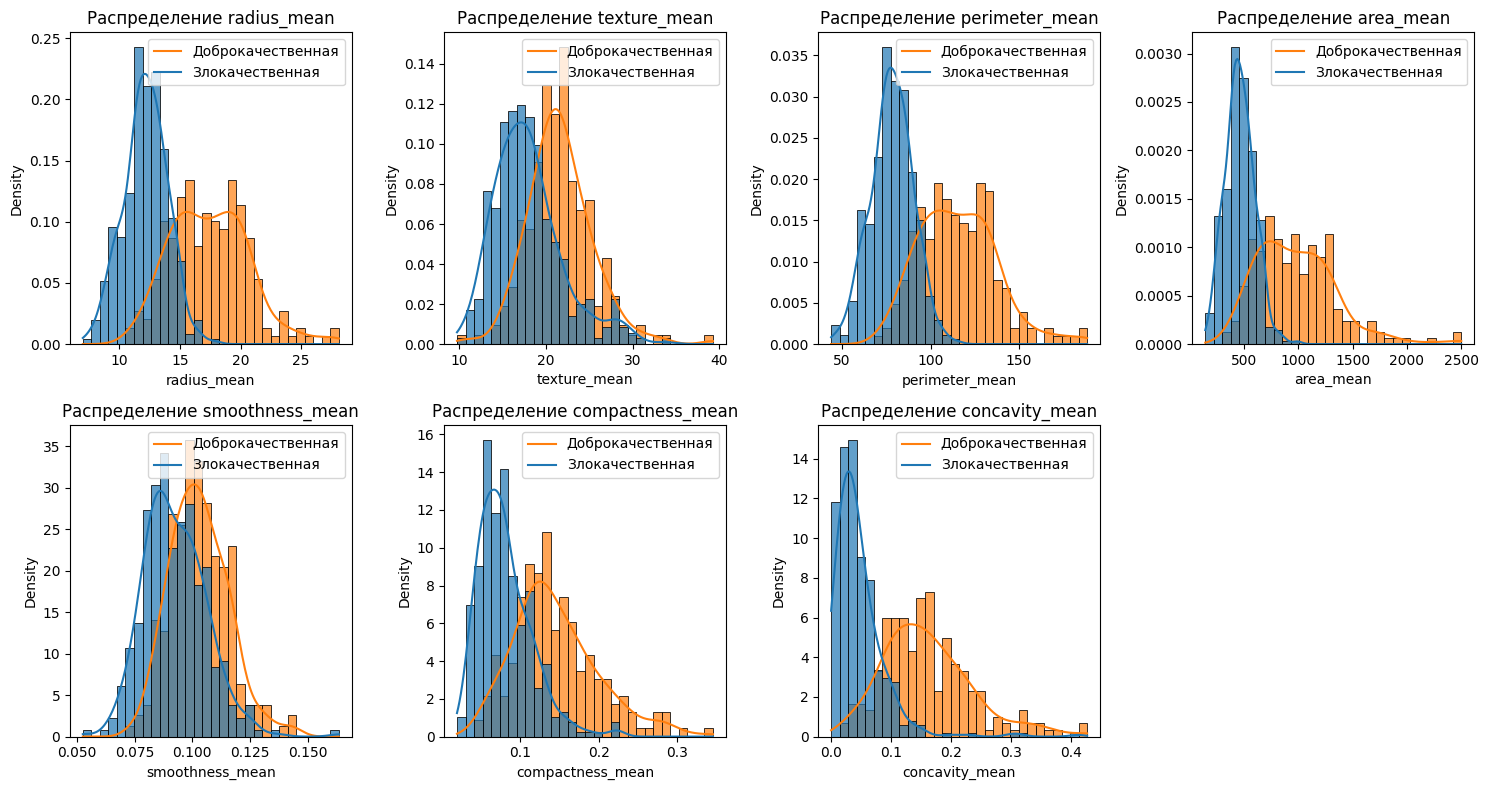

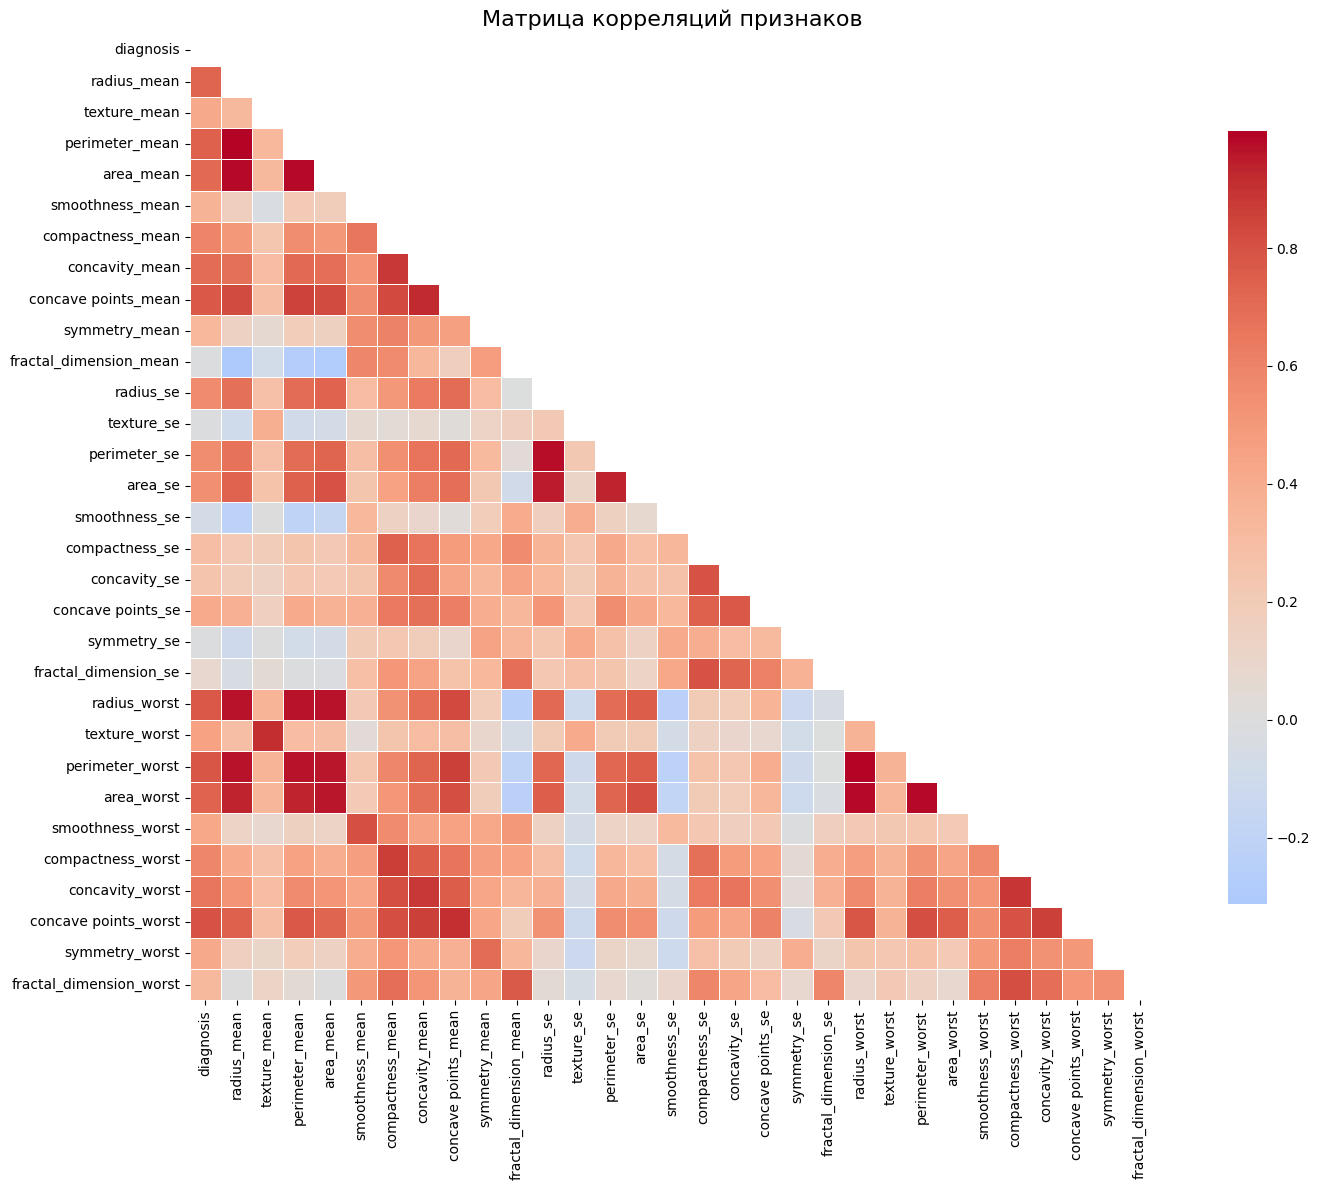


Пары признаков с сильной корреляцией (|r| > 0.9):
radius_mean и perimeter_mean: r = 0.998
radius_mean и area_mean: r = 0.987
radius_mean и radius_worst: r = 0.970
radius_mean и perimeter_worst: r = 0.965
radius_mean и area_worst: r = 0.941
texture_mean и texture_worst: r = 0.912
perimeter_mean и area_mean: r = 0.987
perimeter_mean и radius_worst: r = 0.969
perimeter_mean и perimeter_worst: r = 0.970
perimeter_mean и area_worst: r = 0.942
area_mean и radius_worst: r = 0.963
area_mean и perimeter_worst: r = 0.959
area_mean и area_worst: r = 0.959
concavity_mean и concave points_mean: r = 0.921
concave points_mean и concave points_worst: r = 0.910
radius_se и perimeter_se: r = 0.973
radius_se и area_se: r = 0.952
perimeter_se и area_se: r = 0.938
radius_worst и perimeter_worst: r = 0.994
radius_worst и area_worst: r = 0.984
perimeter_worst и area_worst: r = 0.978

Топ-5 признаков с наибольшей корреляцией с целевой переменной:
diagnosis               1.000000
concave points_worst    0.793

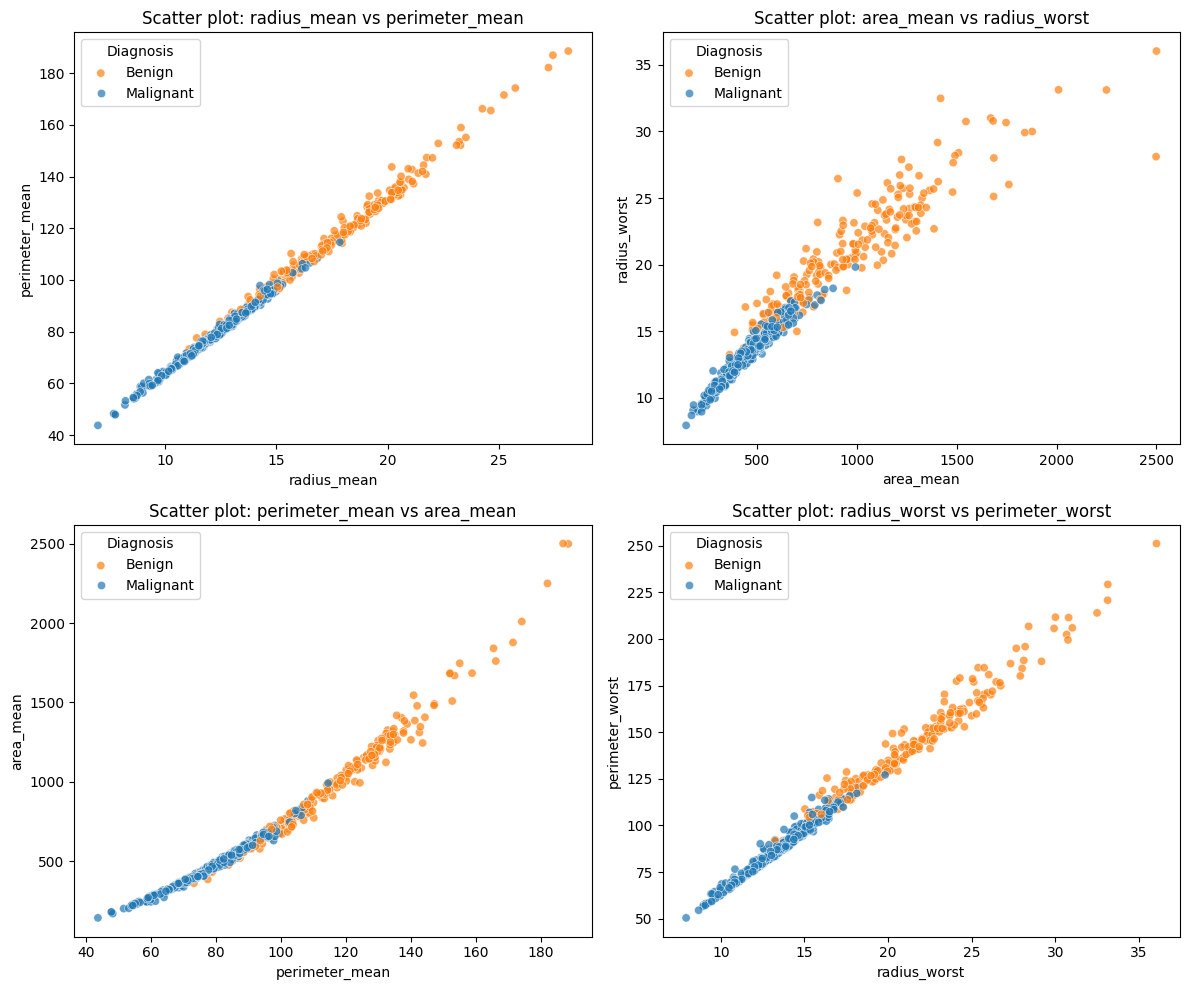

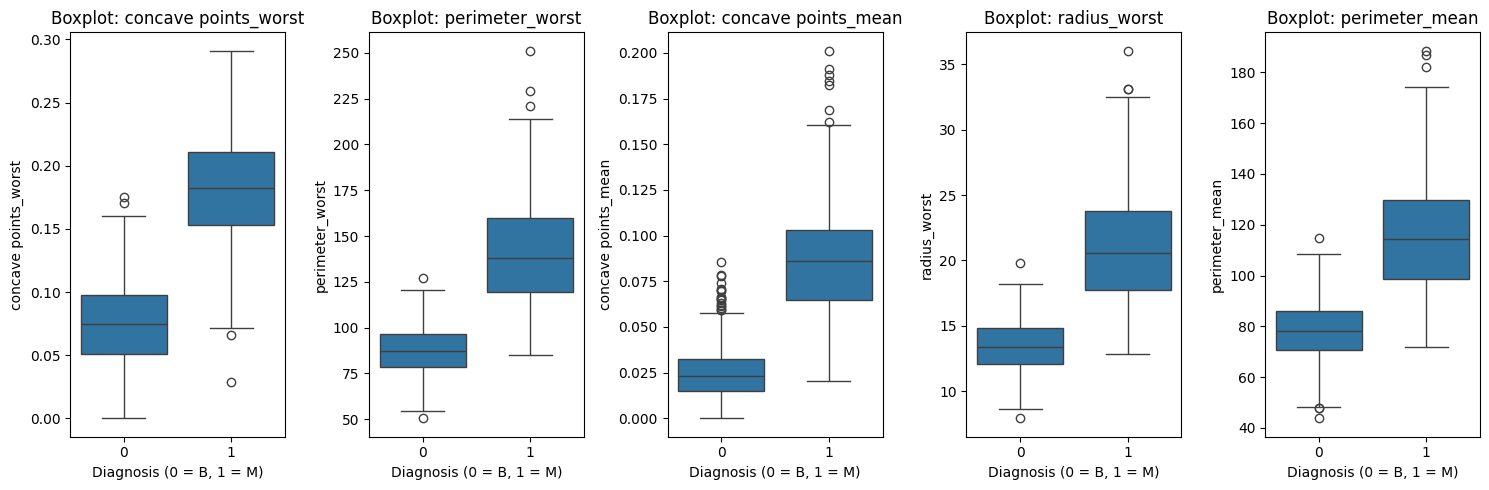

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, classification_report, confusion_matrix
)

# Загружаем датасет
df = pd.read_csv('data.csv')

# Выводим первые 5 строк, чтобы понять структуру
print("Первые 5 строк данных:")
display(df.head())

# Информация о данных: типы столбцов и количество ненулевых значений
df.info()

# Описательная статистика для понимания распределения и масштабов признаков
display(df.describe())

# Удаляем столбец 'id', так как он не несет информационной ценности для модели и удаляем столбец 'Unnamed: 32', который полностью состоит из пропусков (NaN)
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Кодируем целевую переменную 'diagnosis': M -> 1 (злокачественная), B -> 0 (доброкачественная)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Проверяем баланс классов
print(df['diagnosis'].value_counts(normalize=True))

# Визуализация распределений признаков
# Выбираем несколько наиболее важных признаков для визуализации
features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
            'smoothness_mean', 'compactness_mean', 'concavity_mean']

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.ravel()

for i, feature in enumerate(features):
    sns.histplot(data=df, x=feature, hue='diagnosis', bins=30, kde=True,
                 stat='density', common_norm=False, alpha=0.7, ax=axes[i])
    axes[i].set_title(f'Распределение {feature}')
    axes[i].legend(['Доброкачественная', 'Злокачественная'])

# Удаляем лишний подграфик (если признаков меньше, чем мест)
if len(features) < len(axes):
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Вывод: Гистограммы показывают, что для большинства признаков (например, radius_mean, perimeter_mean) распределения для двух классов заметно различаются.
# Признаки, связанные с "размером" опухоли, являются наиболее информативными, так как их значения для злокачественных опухолей смещены в сторону больших величин.
# Это делает их хорошими кандидатами для построения классификатора.

# Матрица корреляций

# Вычисляем матрицу корреляции Пирсона
correlation_matrix = df.corr()

# Строим тепловую карту для визуализации корреляционной матрицы
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций признаков', fontsize=16)
plt.tight_layout()
plt.show()

# Анализ сильно скоррелированных признаков

# Находим пары признаков с высокой корреляцией (|r| > 0.9)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((correlation_matrix.columns[i],
                                    correlation_matrix.columns[j],
                                    correlation_matrix.iloc[i, j]))

print("\nПары признаков с сильной корреляцией (|r| > 0.9):")
for pair in high_corr_pairs:
    print(f"{pair[0]} и {pair[1]}: r = {pair[2]:.3f}")

# Вывод: Видно, что многие признаки сильно коррелируют. Это объясняется тем, что они описывают схожие характеристики опухоли, но в разных единицах или масштабах.
# Например, 'radius_mean' и 'perimeter_mean' почти идеально коррелируют, что логично, так как периметр прямо зависит от радиуса.

# Анализ топ-5 самых значимых признаков
# Корреляция каждого признака с целевой переменной 'diagnosis'
corr_with_target = df.corr()['diagnosis'].sort_values(ascending=False)

print("Топ-5 признаков с наибольшей корреляцией с целевой переменной:")
print(corr_with_target.head(5))

# Вывод: Признаки с суффиксом 'worst' (например, 'concave points_worst', 'perimeter_worst') имеют наибольшую абсолютную корреляцию с диагнозом.
# Это говорит о том, что "худшие" значения опухолевых характеристик являются наиболее информативными для предсказания ее злокачественности.

# Попарные scatter plots для сильно коррелированных признаков

# Возьмем несколько пар признаков, которые сильно коррелируют
feature_pairs = [
    ('radius_mean', 'perimeter_mean'),
    ('area_mean', 'radius_worst'),
    ('perimeter_mean', 'area_mean'),
    ('radius_worst', 'perimeter_worst')
]

# Строим scatter plots для наглядной проверки линейной зависимости
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (f1, f2) in enumerate(feature_pairs):
    sns.scatterplot(data=df, x=f1, y=f2, hue='diagnosis', alpha=0.7, ax=axes[i])
    axes[i].set_title(f'Scatter plot: {f1} vs {f2}')
    axes[i].legend(title='Diagnosis', labels=['Benign', 'Malignant'])

plt.tight_layout()
plt.show()

# Вывод: Scatter plots подтверждают, что сильно коррелированные признаки демонстрируют почти линейную зависимость.
# Также хорошо видно, что злокачественные и доброкачественные опухоли образуют два достаточно четко разделенных кластера по этим признакам.
# Это означает, что модель сможет хорошо разделять классы на основе этих признаков.

# Boxplots для сравнения распределений

# Выберем топ-5 признаков, которые, предположительно, лучше всего разделяют классы.
top_features = ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean']

fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, feature in enumerate(top_features):
    sns.boxplot(data=df, x='diagnosis', y=feature, ax=axes[i])
    axes[i].set_title(f'Boxplot: {feature}')
    axes[i].set_xlabel('Diagnosis (0 = B, 1 = M)')

plt.tight_layout()
plt.show()

**Часть 2. Моделирование при помощи kNN**
ВЫВОДЫ:
* Настройка гиперпараметра k позволила немного улучшить метрики качества. Это демонстрирует важность оптимизации гиперпараметров для достижения лучших результатов.
* На основе анализа кривых валидации, оптимальное число соседей оказалось равным 3.
* Модель kNN показала высокую точность, что подтверждает ее применимость для задачи классификации опухолей молочной железы.

Размер обучающей выборки: 398
Размер тестовой выборки: 171

Метрики для модели kNN (k=5):
Accuracy: 0.9591
Precision: 0.9516
Recall: 0.9365
F1-score: 0.9440


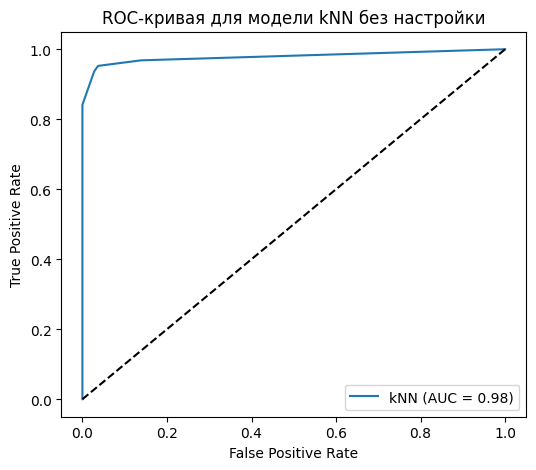


Лучшее значение k: 3
Лучшее значение F1-score на кросс-валидации: 0.9443

Метрики для модели kNN после настройки:
Accuracy: 0.9591
Precision: 0.9516
Recall: 0.9365
F1-score: 0.9440


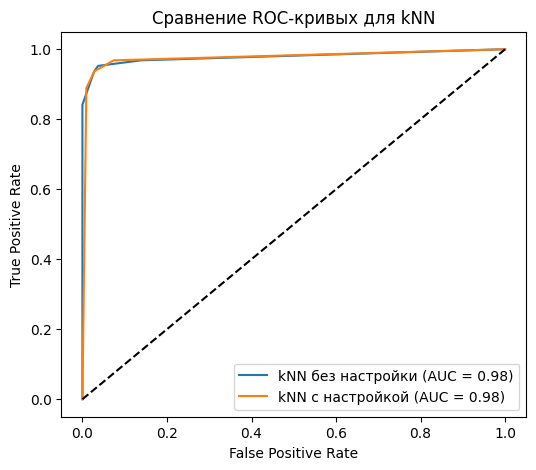

In [ ]:
# Разделение данных на train и test
# Выделяем целевую переменную (y) и матрицу признаков (X)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Разбиваем данные: 70% - для обучения, 30% - для тестирования
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

# Стандартизация признаков
# Масштабируем данные, чтобы все признаки имели одинаковый вес для kNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Важность стандартизации:
# kNN вычисляет расстояния между точками. Если признаки имеют разный масштаб (например, area_mean ~ 1000, а smoothness_mean ~ 0.1),
# то большие по величине признаки будут доминировать в расчете расстояний, нивелируя влияние мелкомасштабных признаков.
# Стандартизация приводит все признаки к единому масштабу (среднее = 0, дисперсия = 1), что делает модель более справедливой и устойчивой.

# Модель kNN без настройки (k=5 по умолчанию)
knn_base = KNeighborsClassifier()
knn_base.fit(X_train_scaled, y_train)

# Оценка модели
y_pred_base = knn_base.predict(X_test_scaled)

print("\nМетрики для модели kNN (k=5):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_base):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_base):.4f}")

# ROC-кривая и AUC
y_pred_proba_base = knn_base.predict_proba(X_test_scaled)[:, 1]
fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_proba_base)
roc_auc_base = auc(fpr_base, tpr_base)

# Визуализация ROC-кривой
plt.figure(figsize=(6, 5))
plt.plot(fpr_base, tpr_base, label=f'kNN (AUC = {roc_auc_base:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для модели kNN без настройки')
plt.legend()
plt.show()

# Настройка параметра k (числа соседей) с помощью кросс-валидации
# Определяем сетку значений для поиска
param_grid = {'n_neighbors': list(range(1, 31))}

# Настраиваем модель с помощью GridSearchCV
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print(f"Лучшее значение k: {grid_search.best_params_['n_neighbors']}")
print(f"Лучшее значение F1-score на кросс-валидации: {grid_search.best_score_:.4f}")

# Оценка настроенной модели
knn_tuned = grid_search.best_estimator_
y_pred_tuned = knn_tuned.predict(X_test_scaled)

print("Метрики для модели kNN после настройки:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_tuned):.4f}")

# ROC-кривая и AUC для настроенной модели
y_pred_proba_tuned = knn_tuned.predict_proba(X_test_scaled)[:, 1]
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_pred_proba_tuned)
roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

# Сравнение ROC-кривых
plt.figure(figsize=(6, 5))
plt.plot(fpr_base, tpr_base, label=f'kNN без настройки (AUC = {roc_auc_base:.2f})')
plt.plot(fpr_tuned, tpr_tuned, label=f'kNN с настройкой (AUC = {roc_auc_tuned:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Сравнение ROC-кривых для kNN')
plt.legend()
plt.show()
